In [ ]:
import pandas as pd

# dataset sera esta

dato1 = [1,2,2,3,4,4,5,6]
dato2 = [2,3,4,4,4,6,5,7]

diccionario = {"x": dato1, "y": dato2}

df= pd.DataFrame(diccionario)

df

,x,y
0,1,2
1,2,3
2,2,4
3,3,4
4,4,4
5,4,6
6,5,5
7,6,7


In [3]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np

# dataset sera esta
dato1 = [1,2,2,3,4,4,5,6]
dato2 = [2,3,4,4,4,6,5,7]
diccionario = {"x": dato1, "y": dato2}
df= pd.DataFrame(diccionario)

# Prepare the data
X = df['x'].values.reshape(-1, 1) # Independent variable (features)
y = df['y'].values # Dependent variable (target)

# Create a linear regression model
model = LinearRegression()

# Fit the model to the data
model.fit(X, y)

# Get the coefficients and intercept
coefficient = model.coef_[0]
intercept = model.intercept_

print(f"Linear Regression Equation: y = {coefficient:.2f}x + {intercept:.2f}")
print(f"Coefficient (slope): {coefficient:.2f}")
print(f"Intercept: {intercept:.2f}")

Linear Regression Equation: y = 0.85x + 1.51
Coefficient (slope): 0.85
Intercept: 1.51


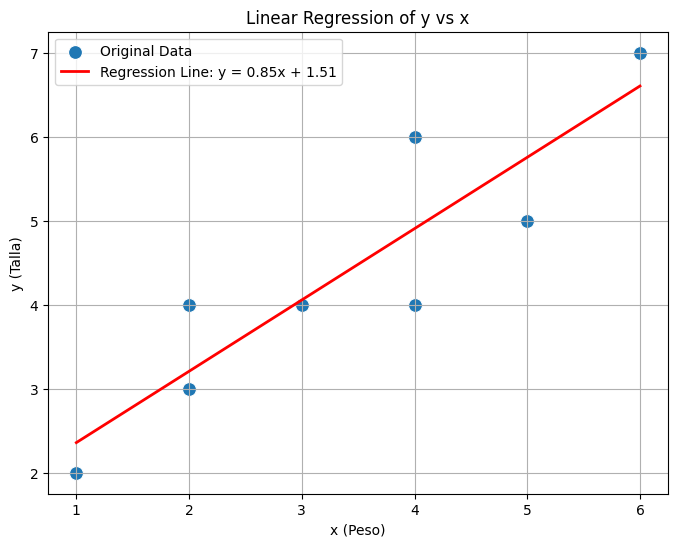

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions using the trained model
y_pred = model.predict(X)

# Plot the original data points and the regression line
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['x'], y=df['y'], s=100, label='Original Data')
plt.plot(df['x'], y_pred, color='red', linewidth=2, label=f'Regression Line: y = {coefficient:.2f}x + {intercept:.2f}')
plt.title('Linear Regression of y vs x')
plt.xlabel('x (Peso)')
plt.ylabel('y (Talla)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df ["xy"] = df.x * df.y

df

,x,y,xy
0,1,2,2
1,2,3,6
2,2,4,8
3,3,4,12
4,4,4,16
5,4,6,24
6,5,5,25
7,6,7,42


In [ ]:
df ["x2"] = df.x **2
df

,x,y,xy,x2
0,1,2,2,1
1,2,3,6,4
2,2,4,8,4
3,3,4,12,9
4,4,4,16,16
5,4,6,24,16
6,5,5,25,25
7,6,7,42,36


In [6]:
suma_columnas = df.sum()
df_con_totales = pd.concat([df, pd.DataFrame([suma_columnas], columns=df.columns, index=['Total'])])
display(df_con_totales)

,x,y,xy,x2
0,1,2,2,1
1,2,3,6,4
2,2,4,8,4
3,3,4,12,9
4,4,4,16,16
5,4,6,24,16
6,5,5,25,25
7,6,7,42,36
Total,27,35,135,111


In [7]:
import pandas as pd

# Re-create the DataFrame and its columns to ensure they are defined
dato1 = [1,2,2,3,4,4,5,6]
dato2 = [2,3,4,4,4,6,5,7]
diccionario = {"x": dato1, "y": dato2}
df= pd.DataFrame(diccionario)

df["xy"] = df.x * df.y
df["x2"] = df.x **2

total_x = df['x'].sum()
total_y = df['y'].sum()
total_xy = df['xy'].sum()
total_x2 = df['x2'].sum()

print(f"Total of column 'x': {total_x}")
print(f"Total of column 'y': {total_y}")
print(f"Total of column 'xy': {total_xy}")
print(f"Total of column 'x2': {total_x2}")

Total of column 'x': 27
Total of column 'y': 35
Total of column 'xy': 135
Total of column 'x2': 111


In [10]:
# el lens sirve para calcular el número de filas de la tabla
n = len(df)

# b1 es la fomrmula para calcular la pendiente de una regresion lineal
b1 = (n * total_xy - total_x * total_y) / (n * total_x2 - (total_x)**2)

# b0 es la formula para calcular el intercepto
b0 = (total_y - b1 * total_x) / n

print(f"Slope (b1): {b1:.4f}")
print(f"Intercept (b0): {b0:.4f}")

Slope (b1): 0.8491
Intercept (b0): 1.5094


In [15]:
import numpy as np

# Calculate residuals (actual y - predicted y)
residuals = df['y'] - y_pred_manual

# Calculate sum of squared residuals
sum_squared_residuals = (residuals ** 2).sum()

# Number of observations (n) - already calculated
# Number of predictors (k) = 1 for simple linear regression (just 'x')

# Degrees of freedom (n - k - 1)
df_error = n - 1 - 1 # n - (number of predictors) - 1 for intercept

# Calculate the standard error of the regression
standard_error = np.sqrt(sum_squared_residuals / df_error)

print(f"Sum of Squared Residuals (SSE): {sum_squared_residuals:.4f}")
print(f"Degrees of Freedom: {df_error}")
print(f"Standard Error of the Regression: {standard_error:.4f}")

Sum of Squared Residuals (SSE): 3.5472
Degrees of Freedom: 6
Standard Error of the Regression: 0.7689


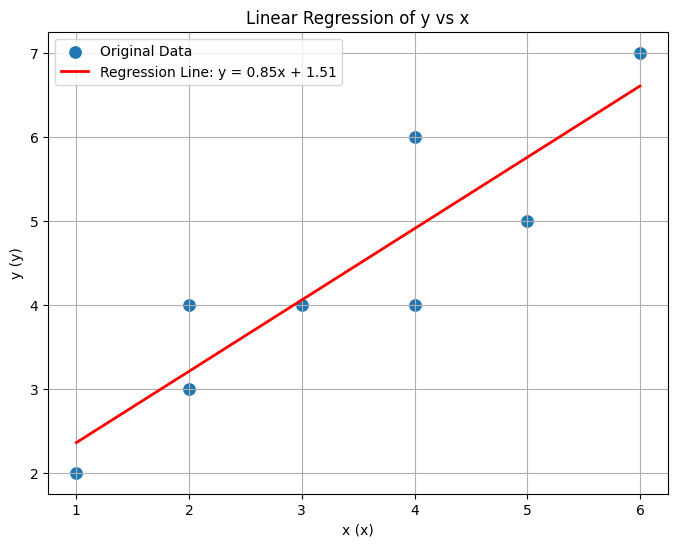

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions using the calculated slope and intercept
y_pred_manual = b1 * df['x'] + b0

# Plot the original data points and the regression line
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['x'], y=df['y'], s=100, label='Original Data')
plt.plot(df['x'], y_pred_manual, color='red', linewidth=2, label=f'Regression Line: y = {b1:.2f}x + {b0:.2f}')
plt.title('Linear Regression of y vs x')
plt.xlabel('x (x)')
plt.ylabel('y (y)')
plt.legend()
plt.grid(True)
plt.show()